# CICIoT2023 Baseline Evaluation

This notebook follows the current repository pipeline:

1. Load processed features from `processed_ciciot23/`
2. Evaluate trained binary and family models from `models/`
3. Save comparison tables and plots for the final report
4. Leave integration cells for spectral features and federated learning

In [1]:
from pathlib import Path
import json
import pickle
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

warnings.filterwarnings("ignore")
matplotlib.rcParams["figure.dpi"] = 120

ROOT = Path(".")
PROCESSED_DIR = ROOT / "processed_ciciot23"
MODEL_DIR = ROOT / "models"

def load_pickle(path: Path):
    with path.open("rb") as handle:
        return pickle.load(handle)

def load_text(path: Path, default: str = "unknown") -> str:
    return path.read_text(encoding="utf-8").strip() if path.exists() else default

print("Setup complete.")

Setup complete.


## 1. Load Processed Validation Data

In [2]:
with (PROCESSED_DIR / "selected_features.json").open("r", encoding="utf-8") as handle:
    selected_features = json.load(handle)["selected_features"]

with (PROCESSED_DIR / "label_family_map.json").open("r", encoding="utf-8") as handle:
    family_map = json.load(handle)

family_names = [family_map[str(index)] for index in range(len(family_map))]

eval_df = pd.read_csv(PROCESSED_DIR / "validation_clean.csv")
X_val = eval_df[selected_features].to_numpy(dtype=np.float32)
y_binary_val = eval_df["label_binary"].to_numpy()
y_family_val = eval_df["label_family_id"].to_numpy()

print(f"Val set shape        : {X_val.shape}")
print(f"Selected features    : {len(selected_features)}")
print(f"Binary class counts  : {np.bincount(y_binary_val)}")
print(f"Family class count   : {len(family_names)}")
display(pd.DataFrame({"feature": selected_features}))

Val set shape        : (1176851, 17)
Selected features    : 17
Binary class counts  : [  27519 1149332]
Family class count   : 15


,feature
0,Header_Length
1,Duration
2,syn_flag_number
3,ack_flag_number
4,syn_count
5,urg_count
6,rst_count
7,HTTPS
8,UDP
9,ICMP


## 2. Preprocessing Summary

In [3]:
metadata_path = PROCESSED_DIR / "preprocess_metadata.json"
if metadata_path.exists():
    with metadata_path.open("r", encoding="utf-8") as handle:
        preprocess_metadata = json.load(handle)

    summary = {
        "Run timestamp": preprocess_metadata.get("run_timestamp"),
        "Rows - train": preprocess_metadata.get("rows", {}).get("train"),
        "Rows - validation": preprocess_metadata.get("rows", {}).get("validation"),
        "Rows - test": preprocess_metadata.get("rows", {}).get("test"),
        "Feature count": preprocess_metadata.get("feature_count"),
        "Correlation threshold": preprocess_metadata.get("correlation_threshold"),
        "Top N per method": preprocess_metadata.get("top_n_per_method"),
        "Test split locked": preprocess_metadata.get("test_split_locked_for_final_reporting"),
    }
    display(pd.DataFrame(summary.items(), columns=["Item", "Value"]))
else:
    print("preprocess_metadata.json not found.")

,Item,Value
0,Run timestamp,2026-04-28T12:27:53Z
1,Rows - train,5491971
2,Rows - validation,1176851
3,Rows - test,1176851
4,Feature count,17
5,Correlation threshold,0.95
6,Top N per method,20
7,Test split locked,True


## 3. Binary Model Comparison

In [4]:
binary_models = ["lr", "rf", "xgb", "lgbm"]
binary_results = []
binary_predictions = {}

for name in binary_models:
    model_path = MODEL_DIR / f"binary_{name}.pkl"
    if not model_path.exists():
        print(f"[SKIP] {model_path} not found")
        continue

    model = load_pickle(model_path)
    y_pred = model.predict(X_val)
    binary_predictions[name.upper()] = y_pred
    binary_results.append(
        {
            "Model": name.upper(),
            "Accuracy": accuracy_score(y_binary_val, y_pred),
            "Precision": precision_score(y_binary_val, y_pred, zero_division=0),
            "Recall": recall_score(y_binary_val, y_pred, zero_division=0),
            "F1": f1_score(y_binary_val, y_pred, zero_division=0),
        }
    )

if binary_results:
    binary_df = pd.DataFrame(binary_results).sort_values("F1", ascending=False)
    display(binary_df.style.format({"Accuracy": "{:.4f}", "Precision": "{:.4f}", "Recall": "{:.4f}", "F1": "{:.4f}"}))
    print(f"Best binary model recorded by training script: {load_text(MODEL_DIR / 'best_binary_name.txt').upper()}")
else:
    print("No binary models found — run train_binary_baseline.py first.")


,Model,Accuracy,Precision,Recall,F1
1,RF,0.9935,0.9973,0.9961,0.9967
3,LGBM,0.9933,0.9973,0.9958,0.9966
2,XGB,0.9911,0.9952,0.9957,0.9954
0,LR,0.9873,0.9922,0.9948,0.9935


Best binary model recorded by training script: RF


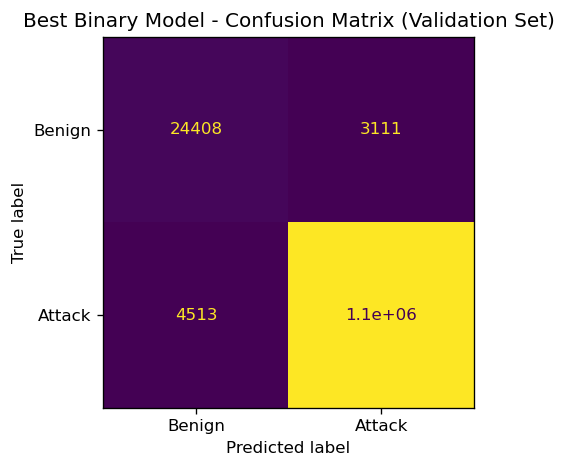

              precision    recall  f1-score   support

      Benign       0.84      0.89      0.86     27519
      Attack       1.00      1.00      1.00   1149332

    accuracy                           0.99   1176851
   macro avg       0.92      0.94      0.93   1176851
weighted avg       0.99      0.99      0.99   1176851



In [5]:
if (MODEL_DIR / "best_binary_model.pkl").exists():
    best_binary_model = load_pickle(MODEL_DIR / "best_binary_model.pkl")
    y_pred_best_binary = best_binary_model.predict(X_val)
    cm = confusion_matrix(y_binary_val, y_pred_best_binary)

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(cm, display_labels=["Benign", "Attack"]).plot(ax=ax, colorbar=False)
    ax.set_title("Best Binary Model - Confusion Matrix (Validation Set)")
    plt.tight_layout()
    MODEL_DIR.mkdir(exist_ok=True)
    plt.savefig(MODEL_DIR / "confusion_matrix_binary.png", dpi=150)
    plt.show()

    print(classification_report(y_binary_val, y_pred_best_binary, target_names=["Benign", "Attack"], zero_division=0))
else:
    print("best_binary_model.pkl not found. Run train_binary_baseline.py first.")

## 4. Family Model Comparison

In [6]:
family_models = ["lr", "rf", "xgb", "lgbm"]
family_results = []
family_predictions = {}

for name in family_models:
    model_path = MODEL_DIR / f"family_{name}.pkl"
    if not model_path.exists():
        print(f"[SKIP] {model_path} not found")
        continue

    model = load_pickle(model_path)
    y_pred = model.predict(X_val)
    family_predictions[name.upper()] = y_pred
    family_results.append(
        {
            "Model": name.upper(),
            "Accuracy": accuracy_score(y_family_val, y_pred),
            "Macro-F1": f1_score(y_family_val, y_pred, average="macro", zero_division=0),
            "Weighted-F1": f1_score(y_family_val, y_pred, average="weighted", zero_division=0),
        }
    )

if family_results:
    family_df = pd.DataFrame(family_results).sort_values("Macro-F1", ascending=False)
    display(family_df.style.format({"Accuracy": "{:.4f}", "Macro-F1": "{:.4f}", "Weighted-F1": "{:.4f}"}))
    print(f"Best family model recorded by training script: {load_text(MODEL_DIR / 'best_family_name.txt').upper()}")
else:
    print("No family models found — run train_family_baseline.py first.")


,Model,Accuracy,Macro-F1,Weighted-F1
1,RF,0.8867,0.4559,0.8762
2,XGB,0.8849,0.4549,0.8745
3,LGBM,0.8515,0.3415,0.8436
0,LR,0.8267,0.2703,0.7742


Best family model recorded by training script: RF


In [7]:
if (MODEL_DIR / "best_family_model.pkl").exists():
    best_family_model = load_pickle(MODEL_DIR / "best_family_model.pkl")
    y_pred_best_family = best_family_model.predict(X_val)

    print(classification_report(
        y_family_val,
        y_pred_best_family,
        labels=list(range(len(family_names))),
        target_names=family_names,
        zero_division=0,
    ))
else:
    print("best_family_model.pkl not found. Run train_family_baseline.py first.")

                      precision    recall  f1-score   support

            Backdoor       0.80      0.04      0.08        93
              Benign       0.76      0.97      0.85     27519
    BrowserHijacking       0.82      0.06      0.11       158
    CommandInjection       0.97      0.23      0.37       132
                DDoS       0.89      0.97      0.93    857523
                 DNS       0.76      0.35      0.48      4565
DictionaryBruteForce       0.85      0.08      0.14       290
                 DoS       0.82      0.51      0.63    203450
                MITM       0.85      0.65      0.74      7741
               Mirai       1.00      0.99      1.00     66091
               Recon       0.77      0.59      0.66      8110
        SqlInjection       0.00      0.00      0.00       148
           Uploading       0.00      0.00      0.00        35
   VulnerabilityScan       0.85      0.81      0.83       905
                 XSS       0.50      0.01      0.02        91

      

## 5. Comparison Plots

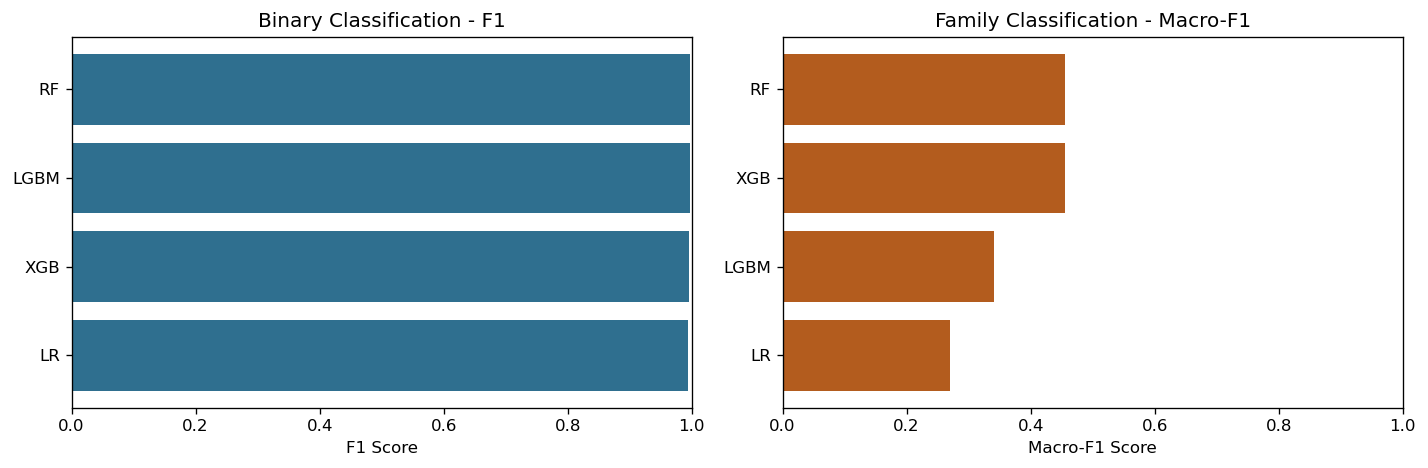

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if binary_results:
    plot_binary = pd.DataFrame(binary_results).sort_values("F1")
    axes[0].barh(plot_binary["Model"], plot_binary["F1"], color="#2f6f8f")
    axes[0].set_xlabel("F1 Score")
    axes[0].set_title("Binary Classification - F1")
    axes[0].set_xlim(0, 1)
else:
    axes[0].text(0.5, 0.5, "No binary results", ha="center", va="center")
    axes[0].set_axis_off()

if family_results:
    plot_family = pd.DataFrame(family_results).sort_values("Macro-F1")
    axes[1].barh(plot_family["Model"], plot_family["Macro-F1"], color="#b35c1e")
    axes[1].set_xlabel("Macro-F1 Score")
    axes[1].set_title("Family Classification - Macro-F1")
    axes[1].set_xlim(0, 1)
else:
    axes[1].text(0.5, 0.5, "No family results", ha="center", va="center")
    axes[1].set_axis_off()

plt.tight_layout()
MODEL_DIR.mkdir(exist_ok=True)
plt.savefig(MODEL_DIR / "model_comparison.png", dpi=150)
plt.show()

## 6. Save Summary CSVs

In [9]:
MODEL_DIR.mkdir(exist_ok=True)

if binary_results:
    pd.DataFrame(binary_results).to_csv(MODEL_DIR / "binary_results.csv", index=False)
    print("Saved: models/binary_results.csv")

if family_results:
    pd.DataFrame(family_results).to_csv(MODEL_DIR / "family_results.csv", index=False)
    print("Saved: models/family_results.csv")

Saved: models/binary_results.csv
Saved: models/family_results.csv
